In [1]:
''' 
Check to see that all channel received the external trigger, fed into the pacman at 1Hz. 
'''

import h5py
import matplotlib.pyplot as plt
import yaml
import numpy as np
import argparse
import json
import tqdm
import io
import tarfile
import os
import math

from matplotlib.patches import Rectangle
from matplotlib.collections import PatchCollection
from matplotlib import cm
from matplotlib.colors import Normalize
from statistics import mean, mode, stdev
from pathlib import Path
from datetime import datetime
from scipy import stats

##########################################################
# Initialize parameters  
##########################################################

# set1-7 datafiles. This file should be run after disabling hot channels, because sometimes hot channels
# impact pedestal values
#filename = "../data/packet-warm_check_ext_trig_all_chan_1hz_120s_7tiles_2026_1_15.hdf5"
filename = "../data/packet-warm_ext-trig_all_chann_300ns_1hz_120s_7tiles.hdf5"

# tiles tested in this filename or the subset of tiles on which you wish to check tally 
tiles = [1,2,3,4,5,6,7]

# serial numbers for set 1-7
chip_serial_number_list = ['', '4k02056', '4k03591', '4k01892', '4k02219', '4k02371', '4k04834', '4k00101' ]
ntiles = 7

# initialize
first_tile = True
percent_low_list, percent_high_list, tile_list = [], [], []

# background: packet dataset attributes: 
# ('io_group', 'io_channel', 'chip_id', 'packet_type', 'downstream_marker', 'parity', 'valid_parity', 'channel_id', 
# 'timestamp', 'dataword', 'trigger_type', 'local_fifo', 'shared_fifo', 'register_address', 'register_data', 'direction', 
# 'local_fifo_events', 'shared_fifo_events', 'counter', 'fifo_diagnostics_enabled', 'first_packet', 'receipt_timestamp')


In [2]:
def get_io_channels(tile):

    # each tile has up to 4 io_channels that uniquely identify the tile within an io_group
    io_ch_per_tile = [
        [],
        [1,2,3,4],
        [5,6,7,8],
        [9,10,11,12],
        [13,14,15,16],
        [17,18,19,20],
        [21,22,23,24],
        [25,26,27,28],
        [29,30,31,32],
        [33,34,35,36],
        [37,38,39,40]
        ]
    
    return io_ch_per_tile[tile]


In [3]:
def get_timestamps(filename, tile, chip_serial_number):
    
    global pedestals, percent_low_list, percent_high_list, tile_list
    
    # initialize
    verbose = False
    npkts_list = []
    slope_list, intercept_list, r_sqr_list, first_t, chip_list = [],[],[], [], []
    
    # read packet data from initialized file name
    f = h5py.File(filename, 'r')
    packets = f['packets'][:]
    
    # create arrays of data packets
    data_mask     = f['packets'][:]['packet_type']  == 1
    data_pkts     = packets[data_mask]

    # identify io_channels with data packets in this data file
    unique_io_channels = list(dict.fromkeys(data_pkts['io_channel'][:]))
    unique_io_channels = sorted(unique_io_channels)

    # print out run statistics for the file
    unixtime = f['packets'][:]['timestamp'][f['packets'][:]['packet_type'] == 4]
    livetime = np.max(unixtime)-np.min(unixtime)        
    npkts         = len(data_pkts)         
    print(f"Run Statistics for tile {tile}:")
    print(f"\t{npkts:,} data packets for tile {tile} arriving at an average rate of {npkts/livetime:.0f} pkts/s over {livetime}s of data taking")         
    
    # get a list of the io_channels that could be enabled for a given tile, and then determine which
    # ones were enabled
    io_channel_ids = get_io_channels(tile)
    enabled_io_channels = list(set(io_channel_ids) & set(unique_io_channels))
    
    # mask for the chosen tile
    tile_mask = (data_pkts['io_channel']== io_channel_ids[0]) | (data_pkts['io_channel']== io_channel_ids[1]) | (data_pkts['io_channel']== io_channel_ids[2]) | (data_pkts['io_channel']== io_channel_ids[3])
    data_pkts = data_pkts[tile_mask]
    
    # check for tiles with no data    
    if len(data_pkts) ==0: 
        print(f'There are no data packets for tile {tile}')        
        return 
    else:
        print(f"\tEnabled io_channels for tile {tile}: {enabled_io_channels}")
 
    # initialize
    npkts_list, nchans = [], 0
    tile_list.append(tile)
    
    # measure the instance rate of missed external triggers, and noisy external trigger lines
    for chip in range(11, 171):

        '''
        if the clock (and receipt of an external trigger) were perfect there would be exactly 120 pkts
        for a datafile of 120s with an external trigger of 1Hz
        '''        
        # mask for channel 0 on each chip
        chip_mask = data_pkts['chip_id'] == chip
        chip_pkts = data_pkts[chip_mask]

        for chan in range(64):
            chan_mask = chip_pkts['channel_id'] == 0
            chan_pkts = chip_pkts[chan_mask]

            npkts = len(chan_pkts)
            npkts_list.append(npkts)

            nchans+=1

    '''
    Fewer pkts than expected may indicate all external triggers were not received. More pkts 
    than expected may indicate the external trigger line is noisy on that chip
    '''
    non_zero_npkts_list = []
    
    for i in range(len(npkts_list)):

        if npkts_list[i] > 0:
            non_zero_npkts_list.append(npkts_list[i])
    
    mode_npkts = mode(non_zero_npkts_list)
    
    print(f"\nTile {tile}: most common # of packets in a channel is {mode_npkts}")
    
    # for each tile record stats for number of pkts
    npkts_low  = sum(1 for x in npkts_list if x < mode_npkts)
    percent_low  = 100*npkts_low /nchans
    percent_low_list.append(percent_low)
    
    npkts_high = sum(1 for x in npkts_list if x > mode_npkts)    
    percent_high = 100*npkts_high /nchans
    percent_high_list.append(percent_high)
    
    npkts_mode = sum(1 for x in npkts_list if x == mode_npkts)   
    percent_mode = 100*npkts_mode/nchans

    print(f"\n------------ Results Tile {tile} --------------")
    
    print(f"{npkts_mode} chips (or {percent_mode:.0f}%) had {mode_npkts} pkts")
    print(f"{ npkts_low} chips (or {percent_low :.0f}%) had fewer pkts, suggesting some external triggers were not received")
    print(f"{npkts_high} chips (or {percent_high:.0f}%) had more pkts, suggesting noise on the external trigger line")
    
    max_npkts = max(npkts_list)

    fig, ax = plt.subplots(1,1, figsize=(6, 3))
    
    # histogram the number of packets for each chip's channel 0
    ax.hist(npkts_list, color = 'g', bins = max_npkts)
    ax.set_title(f"# of Pkts in each Channel (mode {mode_npkts:.0f})\nBenchtop test v3a Tile #{tile} ({chip_serial_number})")
    ax.set_yscale("log")
    ax.text(20, 1000, f"{percent_mode:.0f}% of chips had {mode_npkts} pkts\n{percent_low:.0f}% had fewer pkts\n{percent_high:.0f}% had more pkts", color = "r")
    ax.set_xlabel(f'Number of Packets')
    ax.set_ylabel(f'# of Chips')    
    
    return

Run Statistics for Data File ../data/packet-warm_ext-trig_all_chann_300ns_1hz_120s_7tiles.hdf5:



########################### Run Statistics Tile 1 ###############################
Run Statistics for tile 1:
	6,372,400 data packets for tile 1 arriving at an average rate of 53550 pkts/s over 119s of data taking
	Enabled io_channels for tile 1: [1, 2, 3, 4]

Tile 1: most common # of packets in a channel is 120

------------ Results Tile 1 --------------
5568 chips (or 54%) had 120 pkts
4672 chips (or 46%) had fewer pkts, suggesting some external triggers were not received
0 chips (or 0%) had more pkts, suggesting noise on the external trigger line



########################### Run Statistics Tile 2 ###############################
Run Statistics for tile 2:
	6,372,400 data packets for tile 2 arriving at an average rate of 53550 pkts/s over 119s of data taking
	Enabled io_channels for tile 2: [8, 5, 6, 7]

Tile 2: most common # of packets in a channel is 120

------------ Results Tile 2 -

Text(0, 0.5, 'Percent of Chips')

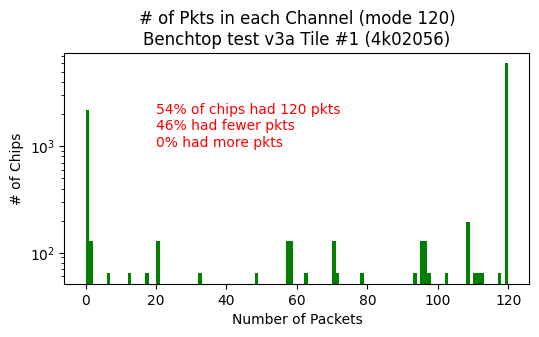

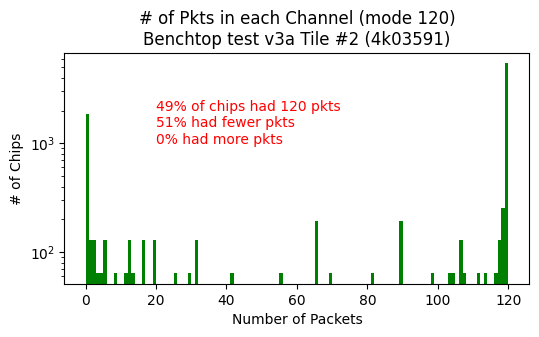

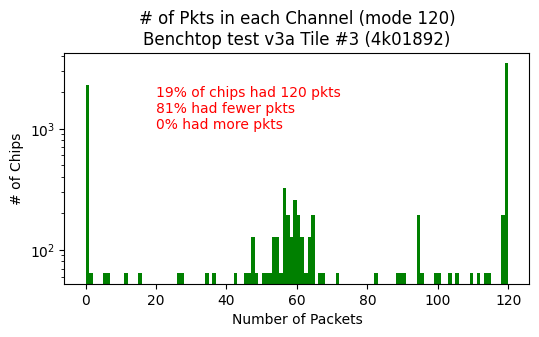

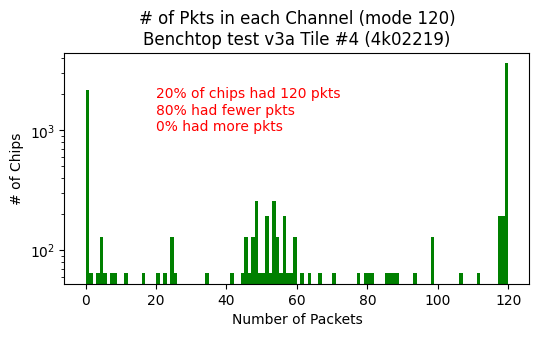

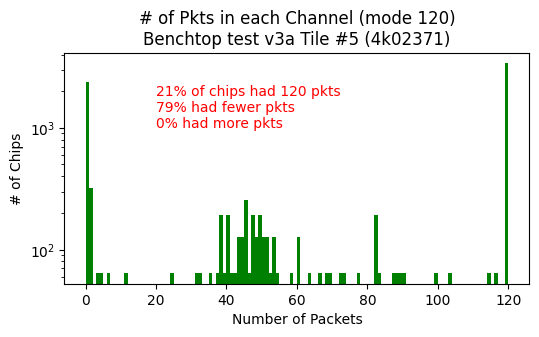

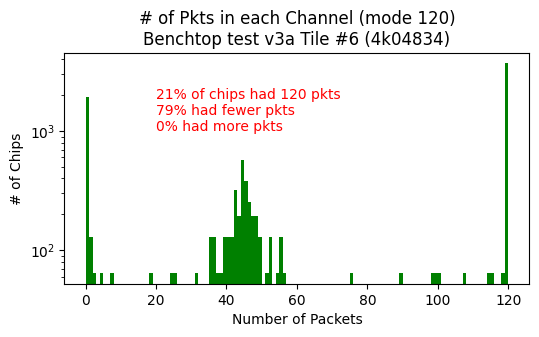

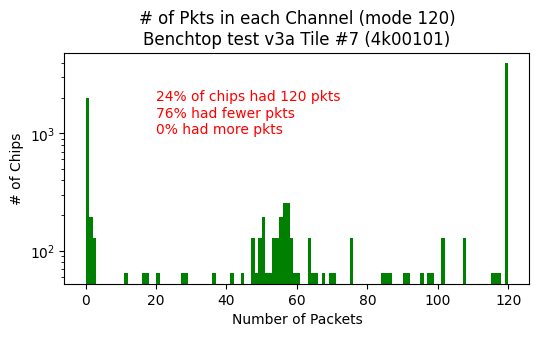

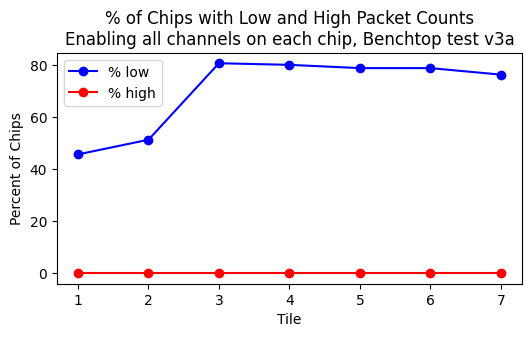

In [4]:
####################
# main
####################

print(f'Run Statistics for Data File {filename}:')

for tile in tiles:
    print(f"\n\n\n########################### Run Statistics Tile {tile} ###############################")
    
    get_timestamps(filename, tile, chip_serial_number_list[tile])

#print(f"percent_low_list: {percent_low_list}")

# graph % of chips that had low and high counts for each tile
fig, ax = plt.subplots(1,1, figsize=(6, 3))

ax.plot(tile_list, percent_low_list , label="% low", color = 'b', marker='o')
ax.plot(tile_list, percent_high_list, label="% high", color = 'r', marker='o')
ax.legend(loc="upper left")
ax.set_title(f"% of Chips with Low and High Packet Counts\nEnabling all channels on each chip, Benchtop test v3a")
ax.set_xlabel("Tile")
ax.set_ylabel("Percent of Chips")
